# Установка зависимостей

In [ ]:
!pip install --no-cache-dir \
    "transformers>=4.36.0,<4.40.0" \
    "onnx>=1.15.0" \
    "onnxruntime>=1.17.0" \
    "torch>=2.1.0" \
    rdkit moses tqdm pandas numpy matplotlib 2>/dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 227.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 186.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 192.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 62.8 MB/s eta 0:00:00
  Created wheel for moses: filename=moses-0.10.0-py3-none-any.whl size=22061 sha256=87a376d5ceeeb51cf3a2222ef1a50002916d61378e2dcb440254fa1ccaf85dfb
  Stored in directory: /tmp/pip-ephem-wheel-cache-1dlyk02c/wheels/d2/4e/aa/3505f3f276c30fe5457e1b9e3ae9091d6e6275c42ef3ad0acd
Successfully built moses
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uni

In [ ]:
import sys
import torch

def patch_transformers_onnx():
    """Создает заглушку для transformers.onnx.OnnxConfig"""
    try:
        from transformers.onnx import OnnxConfig
        return True
    except (ImportError, ModuleNotFoundError):
        onnx_mock = type(sys)('transformers.onnx')
        class DummyOnnxConfig:
            def __init__(self, *args, **kwargs): pass
            @classmethod
            def with_defaults(cls, *args, **kwargs): return None
            @property
            def inputs(self): return {}
            @property
            def outputs(self): return {}
        onnx_mock.OnnxConfig = DummyOnnxConfig
        onnx_mock.export = lambda *a, **k: None
        sys.modules['transformers.onnx'] = onnx_mock
        return False

def patch_orthogonal_batch():
    """
    Патчит orthogonal_batch: QR-разложение всегда в float32,
    даже если модель работает в float16.
    """
    for name, module in list(sys.modules.items()):
        if 'modeling_molformer' in name and hasattr(module, 'orthogonal_batch'):
            original = module.orthogonal_batch
            def safe_orthogonal_batch(size, device=None, dtype=None):
                if device is None:
                    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                target_dtype = dtype if dtype is not None else torch.get_default_dtype()
                # Всегда float32 для QR
                block = torch.randn(size, size, device=device, dtype=torch.float32)
                norms = torch.linalg.norm(block, dim=1, keepdim=True)
                Q, _ = torch.linalg.qr(block)
                return (Q * norms).to(target_dtype)
            module.orthogonal_batch = safe_orthogonal_batch
            return True
    return False

patch_transformers_onnx()
print("Патч transformers.onnx применен")

Патч transformers.onnx применен


In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*linear attention.*efficiency.*')
warnings.filterwarnings('ignore', message='.*linear attention.*')
warnings.filterwarnings('ignore', message='.*efficiency gains.*')

from io import StringIO
from contextlib import redirect_stderr, redirect_stdout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from rdkit import Chem
from rdkit.Chem import Draw, QED, Descriptors
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from IPython.display import display, Markdown
import torch
from google.colab import files

# Обоснование набора ингибиторов для генерации

Выбор меланомы в качестве объекта исследования обусловлен сочетанием высокой социальной значимости заболевания и личной мотивацией. Мой опыт столкновения с подозрением на меланому в подростковом возрасте и успешное хирургическое вмешательство подчеркнули важность своевременной диагностики и разработки эффективных методов терапии.

Мутация BRAF V600E, нарушающая сигнальный путь MAPK/ERK, встречается примерно в 50% случаев меланомы. Ингибиторы BRAF демонстрируют высокую эффективность в терапии, однако к ним быстро развивается резистентность [De, A., Kouznetsova, V.L. & Tsigelny, I.F. Machine learning enabled elucidation of novel BRAF V600E inhibitors for metastatic melanoma treatment. BMC Methods 2, 31 (2025).].



Так в качестве мишени заболевания была выбрана серин/треонин-протеинкиназа B-raf (CHEMBL5145), а набор ингибиторов (из пункта "Approved Drugs and Clinical Candidates" этого белка в базе ChEMBL): вемурафениб (CHEMBL1229517), регорафениб (CHEMBL1946170), дабрафениб (CHEMBL2028663), энкорафениб (CHEMBL3301612) и сорафениб (CHEMBL1336).

In [ ]:
molecules_braf = {
    'VEMURAFENIB': 'CCCS(=O)(=O)Nc1ccc(F)c(C(=O)c2c[nH]c3ncc(-c4ccc(Cl)cc4)cc23)c1F',
    'REGORAFENIB': 'CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)c(F)c2)ccn1',
    'DABRAFENIB': 'CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2F)c(-c2ccnc(N)n2)s1',
    'ENCORAFENIB': 'COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2-c2cc(Cl)cc(NS(C)(=O)=O)c2F)n1',
    'SORAFENIB': 'CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1',
}

# Загрузка токенизатора и генеративной модели

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Загрузка токенизатора
tokenizer = AutoTokenizer.from_pretrained('ibm-research/MoLFormer-XL-both-10pct', trust_remote_code=True)

# Загрузка генеративной модели
emb_model = AutoModelForCausalLM.from_pretrained(
    'ibm-research/GP-MoLFormer-Uniq',
    trust_remote_code=True,
    torch_dtype=torch.float32  # Во избежание ошибки geqrf_cuda + Half
).to(device)
emb_model.eval()

# Применяем патч orthogonal_batch
patch_orthogonal_batch()
print("Патч orthogonal_batch применен")
print("Модель готова к генерации!")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_molformer_fast.py: 0.00B [00:00, ?B/s]

tokenization_molformer.py: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/ibm-research/GP-MoLFormer-Uniq:
- configuration_molformer.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_molformer.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ibm-research/GP-MoLFormer-Uniq:
- modeling_molformer.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/187M [00:00<?, ?B/s]

Патч orthogonal_batch применен
Модель готова к генерации!


# Извлечение эмбеддингов

In [ ]:
def get_embedding_and_tokens(smiles, agg='mean', model=None, tok=None, dev=None):
    if model is None or tok is None or dev is None:
        raise ValueError("Укажите model, tok и dev параметры")

    with redirect_stderr(StringIO()), redirect_stdout(StringIO()):
        inputs = tok(smiles, return_tensors='pt').to(dev)
        input_ids = inputs['input_ids'].squeeze(0).cpu().tolist()
        tokens = tok.convert_ids_to_tokens(input_ids)

        with torch.no_grad():
            outputs = model(
                **inputs,
                output_hidden_states=True,
                output_attentions=False
            )

        if outputs.hidden_states and len(outputs.hidden_states) > 0:
            last_hidden = outputs.hidden_states[-1].squeeze(0).cpu().numpy()
        else:
            last_hidden = outputs.logits.squeeze(0).cpu().numpy()
            if last_hidden.ndim == 2 and last_hidden.shape[0] > len(tokens):
                last_hidden = last_hidden[:len(tokens)]

        if last_hidden.shape[0] != len(tokens):
            min_len = min(last_hidden.shape[0], len(tokens))
            tokens = tokens[:min_len]
            last_hidden = last_hidden[:min_len]

        emb = last_hidden.mean(axis=0) if agg == 'mean' else last_hidden[0]
        attentions = None

        return emb, last_hidden, tokens, attentions

In [ ]:
# Вычисляем эмбеддинги для набора молекул
embeddings = {}
token_info = {}
attentions_info = {}

for name, smi in molecules_braf.items():
    try:
        emb, token_embs, tokens, atts = get_embedding_and_tokens(
            smi, agg='mean', model=emb_model, tok=tokenizer, dev=device
        )
        embeddings[name] = emb
        token_info[name] = {'tokens': tokens, 'token_embs': token_embs}
        print(f"{name}: {len(tokens)} токенов, эмбеддинг {emb.shape}")
    except Exception as e:
        print(f"{name}: ошибка - {e}")
        import traceback
        traceback.print_exc()

VEMURAFENIB: 61 токенов, эмбеддинг (768,)
REGORAFENIB: 61 токенов, эмбеддинг (768,)
DABRAFENIB: 67 токенов, эмбеддинг (768,)
ENCORAFENIB: 67 токенов, эмбеддинг (768,)
SORAFENIB: 58 токенов, эмбеддинг (768,)


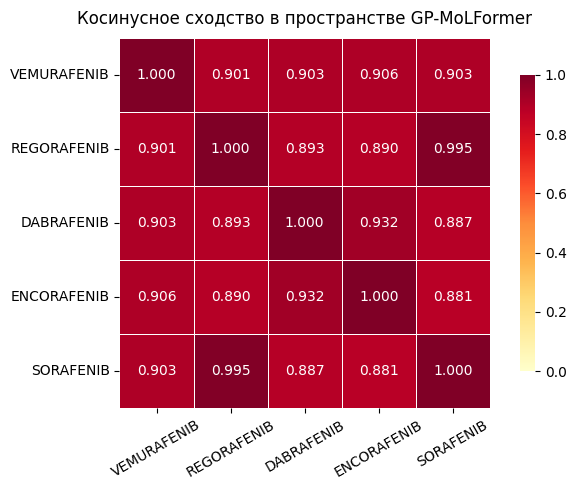

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Матрица эмбеддингов
names = list(embeddings.keys())
emb_matrix = np.vstack([embeddings[n] for n in names])

# Косинусное сходство в пространстве модели
cos_sim = cosine_similarity(emb_matrix)

# Визуализация
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cos_sim,
    ax=ax,
    annot=True, fmt='.3f',
    xticklabels=names, yticklabels=names,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Косинусное сходство в пространстве GP-MoLFormer', fontsize=12, pad=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

Молекулы близки в латентном пространстве

# Выбор начальной точки генерации

Выбор энкорафениба обусловлен наибольшим количеством тяжелых атомов (чем у других в выборке). Самый низкий показатель AlogP гарантирует лучшую гидрофильность и растворимость производных. При этом максимальная площадь полярной поверхности (PSA) создает фундамент для формирования высокоспецифичных связей с биологической мишенью в процессе дизайна новых соединений

Структура энкорафениба


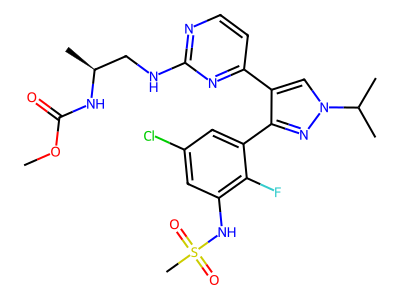

MW: 540.0 Da | QED: 0.372 | LogP: 3.91


In [ ]:
print("Структура энкорафениба")
ENCORAFENIB_smiles = molecules_braf['ENCORAFENIB']
ENCORAFENIB_mol = Chem.MolFromSmiles(ENCORAFENIB_smiles)

if ENCORAFENIB_mol:
    img = Draw.MolToImage(ENCORAFENIB_mol, size=(400, 300), kekulize=True)
    display(img)
    print(f"MW: {Descriptors.MolWt(ENCORAFENIB_mol):.1f} Da | QED: {QED.qed(ENCORAFENIB_mol):.3f} | LogP: {Descriptors.MolLogP(ENCORAFENIB_mol):.2f}")

Определение фрагмента молекулы

Фрагмент энкорафениба


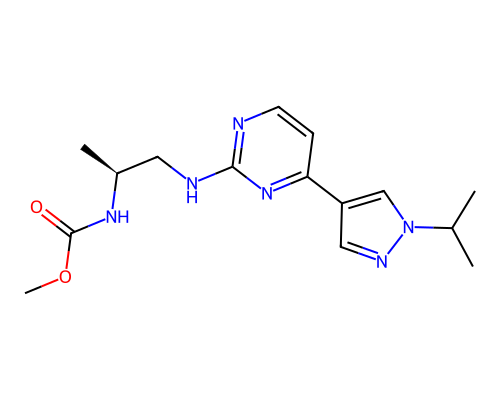

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

print("Фрагмент энкорафениба")

fragment_smiles = 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2'

fragment_mol = Chem.MolFromSmiles(fragment_smiles)

if fragment_mol:
    img = Draw.MolToImage(fragment_mol, size=(500, 400))
    display(img)

# Генерация

In [ ]:
def generate_smiles(fragment, batch_size=20, temperature=1.0, max_length=None,
                   seed=None, model=None, tok=None, dev=None):
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    if max_length is None:
        try:
            max_length = model.config.max_position_embeddings
        except:
            max_length = 200

    inputs = tok(fragment, return_tensors='pt').to(dev)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            top_p=0.95,
            top_k=50,
            max_length=max_length,
            num_return_sequences=batch_size,
            pad_token_id=tok.pad_token_id if hasattr(tok, 'pad_token_id') else tok.eos_token_id,
            eos_token_id=tok.eos_token_id,
            repetition_penalty=1.1
        ).cpu()

    decoded = tok.batch_decode(outputs, skip_special_tokens=True)
    cleaned = [d.strip().split()[0].replace('<unk>', '').replace(' ', '') for d in decoded if isinstance(d, str) and d.strip()]
    return cleaned

In [ ]:
print("Генерация на основе фрагмента энкорафениб")

print(f"Фрагмент: COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2")

temps = [0.3, 0.5, 0.7, 0.9, 1.1]
batch_size = 500
seed = 42

results = {}
summary_data = []

for t in temps:
    print(f"\n Температура = {t}...")
    gen = generate_smiles(fragment_smiles, batch_size=batch_size, temperature=t, seed=seed,
                         model=emb_model, tok=tokenizer, dev=device)
    valid = [s for s in gen if Chem.MolFromSmiles(s) is not None]
    unique_valid = list(set(valid))

    stats = {
        'temperature': t,
        'generated': len(gen),
        'valid': len(valid),
        'valid_rate': len(valid)/len(gen)*100 if gen else 0,
        'unique_valid': len(unique_valid),
        'avg_qed': np.mean([QED.qed(Chem.MolFromSmiles(s)) for s in valid]) if valid else 0,
    }
    summary_data.append(stats)
    results[t] = {'raw': gen, 'valid': valid, 'unique': unique_valid}

    print(f"Сгенерировано: {stats['generated']} | Валидных: {stats['valid']} ({stats['valid_rate']:.1f}%) | QED: {stats['avg_qed']:.3f}")

Генерация на основе фрагмента энкорафениб
Фрагмент: COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2

 Температура = 0.3...


[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21CCCC2'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2cccc12'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cccc12'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21C(=O)N(C)Cc1cc(F)cc(Cl)c1'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21CCCC2'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21C(=O)Nc1cc(F)cc(F)c1-2'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2cccc12'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2cccc12'
[15:38:49] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c

Сгенерировано: 500 | Валидных: 0 (0.0%) | QED: 0.000

 Температура = 0.5...


[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cccc1-2'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2ccc(Cl)c12'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cccc12'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2cccc12'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21CCCC2'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21C(=O)Nc1cc(F)cc(F)c1-2'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2cccc12'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cccc1-2'
[15:38:56] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)

Сгенерировано: 500 | Валидных: 0 (0.0%) | QED: 0.000

 Температура = 0.7...


[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cccc1-2'
[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2ccc(OC)c12'
[15:39:03] SMILES Parse Error: ring closure 1 duplicates bond between atom 37 and atom 38 for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(NCC(C)NC(=O)OC(C)(C)C)ncc1-c1cnc(C(F)(F)F)nc1'
[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cc(Cl)cc1-2'
[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21ccc(F)c2F'
[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2cccc12'
[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cc(C)cc1-2'
[15:39:03] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(Cl)ccc1-2'
[15:39:03] S

Сгенерировано: 500 | Валидных: 18 (3.6%) | QED: 0.847

 Температура = 0.9...


[15:39:08] Can't kekulize mol.  Unkekulized atoms: 15 16 21
[15:39:08] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2ccc(OC)c12'
[15:39:08] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(NCC(C)NC(=O)OC(C)(C)C)ncc12'
[15:39:08] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)cc(Cl)c12.Cl.Cl'
[15:39:08] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21ccc(F)c2F'
[15:39:08] SMILES Parse Error: ring closure 1 duplicates bond between atom 25 and atom 26 for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2ncc1-c1ccc(C)cc1'
[15:39:08] SMILES Parse Error: ring closure 1 duplicates bond between atom 27 and atom 28 for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)nc(N)c1-c1ccc(F)c(Cl)c1'
[15:39:08] SMILES Parse Error: ring closure 1 duplicates bond between atom 24 and atom 25 for input: 'COC(=O)N[C@@H](C)CNc1n

Сгенерировано: 500 | Валидных: 31 (6.2%) | QED: 0.847

 Температура = 1.1...
Сгенерировано: 500 | Валидных: 63 (12.6%) | QED: 0.759


[15:39:14] Can't kekulize mol.  Unkekulized atoms: 15 16 21
[15:39:14] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2ccc(OC)n12.[Cl-]'
[15:39:14] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(NCC(C)NC(=O)OC(C)(C)C)nc[n+]1C'
[15:39:14] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc21ccc(F)c2F'
[15:39:14] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2ncc1Cl'
[15:39:14] SMILES Parse Error: ring closure 1 duplicates bond between atom 27 and atom 28 for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C)nc(N)c1-c1ccc(F)c(Cl)c1'
[15:39:14] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2C(F)c2cc(F)ccc1-2'
[15:39:14] SMILES Parse Error: unclosed ring for input: 'COC(=O)N[C@@H](C)CNc1nccc(n1)-c2cn(C(C)C)nc2(C(=O)Cc2ccccn2)Sc1Cl'
[15:39:14] SMILES Parse Error: unclosed ring fo

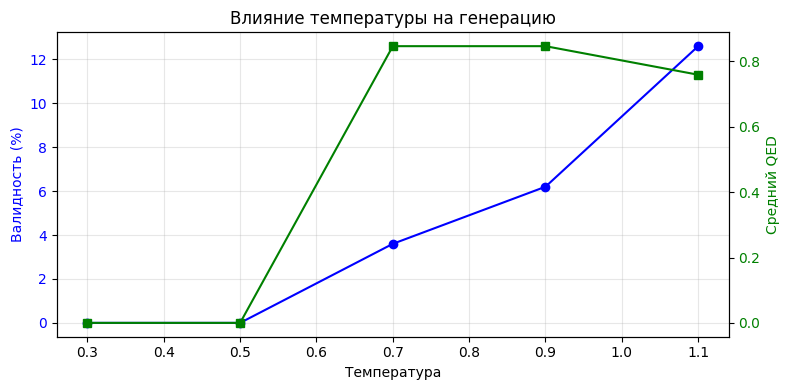

In [ ]:
if summary_data:
    df_summary = pd.DataFrame(summary_data)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(df_summary['temperature'], df_summary['valid_rate'], marker='o', color='blue', label='Валидность (%)')
    ax1.set_xlabel('Температура')
    ax1.set_ylabel('Валидность (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(df_summary['temperature'], df_summary['avg_qed'], marker='s', color='green', label='QED')
    ax2.set_ylabel('Средний QED', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    plt.title('Влияние температуры на генерацию')
    plt.tight_layout()
    plt.show()

* Низкие температуры (0.3-0.5) неэффективны - в этом диапазоне обе метрики находятся на нулевом уровне

* Критический порог (0.7)- при повышении температуры до 0.7 происходит резкий скачок качества. Средний QED (зеленая линия) мгновенно вырастает до максимального значения (0.85). Валидность (синяя линия) начинает расти, достигая примерно 4%

* Оптимальный диапазон (0.7 – 0.9) - этот интервал выглядит наиболее сбалансированным для качества. Показатель QED остается на пике, а валидность продолжает уверенно расти

* Высокая температура (1.1) - компромисс количества и качества. Валидность достигает своего максимума (примерно 12%). Это значит, что модель генерирует больше валидных объектов. Но средний QED начинает падать (до 0.75). Это говорит о том, что хотя валидных структур становится больше, их лекарственноподобие ухудшается из-за излишней случайности

# Сохранение результатов

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Схожесть с энкорафенибом
ENCORAFENIB_emb, *_ = get_embedding_and_tokens(
    ENCORAFENIB_smiles, model=emb_model, tok=tokenizer, dev=device
)

def sim_to_ENCORAFENIB(s):
    emb, *_ = get_embedding_and_tokens(s, model=emb_model, tok=tokenizer, dev=device)
    return cosine_similarity(ENCORAFENIB_emb.reshape(1,-1), emb.reshape(1,-1))[0,0]

all_results = []
seen_canon = set()

for t in temps:
    for smi in results[t]['valid']:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            canon_s = Chem.MolToSmiles(mol)
            if canon_s not in seen_canon:
                seen_canon.add(canon_s)
                all_results.append({
                    'temperature': t,
                    'smiles': canon_s,
                    'similarity_to_ENCORAFENIB': sim_to_ENCORAFENIB(canon_s),
                    'qed': QED.qed(mol),
                    'mw': Descriptors.MolWt(mol),
                    'logp': Descriptors.MolLogP(mol),
                })

In [ ]:
# Сохранение и скачивание CSV
if all_results:
    df_all = pd.DataFrame(all_results)
    df_all = df_all.sort_values('similarity_to_ENCORAFENIB', ascending=False)

    csv_name = "generated_valid_molecules_ENCORAFENIB.csv"
    df_all.to_csv(csv_name, index=False, encoding="utf-8-sig")
    print(f"Сохранено {len(df_all)} уникальных молекул в '{csv_name}'")

    files.download(csv_name)

Сохранено 22 уникальных молекул в 'generated_valid_molecules_ENCORAFENIB.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>